# Formula 1 Optimal Pit Stop Timing Model

In [355]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy import stats
from scipy.stats import chi2_contingency, entropy
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import (average_precision_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_curve)

import fastf1
import time
import os
from fastf1.exceptions import RateLimitExceededError
import warnings
warnings.filterwarnings("ignore")

fastf1.Cache.enable_cache("fastf1_cache")

In [74]:
lap_data = pd.read_csv("f1_pit_stop_data.csv")
lap_data

,Driver,DriverNumber,Team,LapNumber,LapTime,PitInTime,PitOutTime,Stint,Compound,TyreLife,...,Humidity,WindSpeed,WindDirection,LapTime_s,PitInTime_s,PitOutTime_s,Sector1Time_s,Sector2Time_s,Sector3Time_s,Time_s
0,LEC,16,Ferrari,1.0,0 days 00:01:39.070000,NaN,NaN,1.0,SOFT,1.0,...,26.0,0.3,13,99.070,NaN,NaN,NaN,42.120,23.984,3854.174
1,VER,1,Red Bull Racing,1.0,0 days 00:01:40.236000,NaN,NaN,1.0,SOFT,4.0,...,26.0,0.3,13,100.236,NaN,NaN,NaN,42.325,24.389,3855.340
2,SAI,55,Ferrari,1.0,0 days 00:01:41.006000,NaN,NaN,1.0,SOFT,4.0,...,26.0,0.3,13,101.006,NaN,NaN,NaN,42.889,24.253,3856.110
3,HAM,44,Mercedes,1.0,0 days 00:01:41.555000,NaN,NaN,1.0,SOFT,3.0,...,26.0,0.3,13,101.555,NaN,NaN,NaN,42.966,24.137,3856.659
4,MAG,20,Haas F1 Team,1.0,0 days 00:01:42.333000,NaN,NaN,1.0,SOFT,1.0,...,26.0,0.3,13,102.333,NaN,NaN,NaN,43.366,24.340,3857.437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101292,BOR,5,Kick Sauber,58.0,0 days 00:01:30.667000,NaN,NaN,2.0,HARD,43.0,...,66.0,0.8,104,90.667,NaN,NaN,17.901,38.794,33.972,8749.246
101293,SAI,55,Williams,58.0,0 days 00:01:30.046000,NaN,NaN,2.0,HARD,40.0,...,66.0,0.8,104,90.046,NaN,NaN,17.814,38.404,33.828,8750.361
101294,TSU,22,Red Bull Racing,58.0,0 days 00:01:29.566000,NaN,NaN,2.0,MEDIUM,26.0,...,66.0,0.8,104,89.566,NaN,NaN,17.690,38.459,33.417,8751.997
101295,ANT,12,Mercedes,58.0,0 days 00:01:29.630000,NaN,NaN,2.0,MEDIUM,26.0,...,66.0,0.8,104,89.630,NaN,NaN,17.848,37.897,33.885,8752.602


In [75]:
lap_data.info()
lap_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101297 entries, 0 to 101296
Data columns (total 38 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Driver         101297 non-null  object 
 1   DriverNumber   101297 non-null  int64  
 2   Team           101297 non-null  object 
 3   LapNumber      101297 non-null  float64
 4   LapTime        99751 non-null   object 
 5   PitInTime      3469 non-null    object 
 6   PitOutTime     3467 non-null    object 
 7   Stint          100851 non-null  float64
 8   Compound       100425 non-null  object 
 9   TyreLife       100216 non-null  float64
 10  FreshTyre      101297 non-null  bool   
 11  Sector1Time    99196 non-null   object 
 12  Sector2Time    101121 non-null  object 
 13  Sector3Time    101008 non-null  object 
 14  SpeedI1        101154 non-null  float64
 15  SpeedI2        100270 non-null  float64
 16  SpeedFL        97688 non-null   float64
 17  SpeedST        101109 non-nul

,DriverNumber,LapNumber,Stint,TyreLife,SpeedI1,SpeedI2,SpeedFL,SpeedST,TrackStatus,Position,...,Humidity,WindSpeed,WindDirection,LapTime_s,PitInTime_s,PitOutTime_s,Sector1Time_s,Sector2Time_s,Sector3Time_s,Time_s
count,101297.000000,101297.000000,100851.000000,100216.000000,101154.000000,100270.000000,97688.000000,101109.000000,101297.000000,101155.000000,...,101297.000000,101297.000000,101297.000000,99751.000000,3469.00000,3467.000000,99196.000000,101121.000000,101008.000000,101297.000000
mean,27.879908,30.440378,2.062488,14.384769,254.058950,246.338775,265.620455,295.700304,11.145621,9.759270,...,53.276148,1.813391,182.474980,92.039522,6329.94356,6426.602369,28.658502,35.551019,28.200079,6614.702304
std,23.478958,18.311047,0.956123,10.312966,48.267998,46.069675,36.823895,33.871076,118.720927,5.408101,...,17.609433,1.099131,98.648402,33.463977,1838.63235,1927.191385,7.403517,8.162187,7.695483,2018.757260
min,1.000000,1.000000,1.000000,1.000000,31.000000,40.000000,1.000000,54.000000,1.000000,1.000000,...,5.000000,0.000000,0.000000,67.012000,920.35300,257.809000,16.835000,17.488000,16.536000,349.596000
25%,10.000000,15.000000,1.000000,6.000000,215.000000,211.000000,246.000000,289.000000,1.000000,5.000000,...,40.000000,1.100000,112.000000,81.578000,4890.66400,4996.792000,24.286750,29.921000,23.162000,5047.244000
50%,22.000000,30.000000,2.000000,12.000000,273.000000,255.000000,273.000000,302.000000,1.000000,10.000000,...,55.000000,1.600000,182.000000,89.922000,6181.69000,6215.201000,28.709000,33.597000,26.198000,6499.434000
75%,44.000000,45.000000,3.000000,20.000000,288.000000,280.000000,289.000000,313.000000,1.000000,14.000000,...,66.000000,2.300000,265.000000,99.087000,7421.72800,7508.240500,31.611000,41.204000,31.596000,7973.757000
max,87.000000,78.000000,8.000000,78.000000,357.000000,347.000000,359.000000,364.000000,16724.000000,20.000000,...,92.000000,8.600000,359.000000,2526.253000,14312.82600,14342.734000,98.794000,92.611000,99.740000,15109.536000


## Pit Strategy Model

### Data Cleaning and Feature Engineering

In [218]:
def clean_data(lap_data):
    df = lap_data.copy()

    # drop impossible lap times
    df = df[(df["LapTime_s"] > 60) & (df["LapTime_s"] < 250)].copy()

    # drop retirement laps
    df["MaxDriverLap"] = df.groupby(["Year", "EventName", "Driver"])["LapNumber"].transform("max")
    df["MaxEventLap"]  = df.groupby(["Year", "EventName"])["LapNumber"].transform("max")
    dnf_lap = ((df["MaxDriverLap"] < df["MaxEventLap"] - 2) & (df["LapNumber"] == df["MaxDriverLap"]))
    df = df[~dnf_lap].copy()

    # filling missing compound within each stint
    df["Compound"] = (df.groupby(["Driver", "Year", "EventName", "Stint"])["Compound"].transform(lambda x: x.ffill().bfill()).fillna("UNKNOWN"))

    # flagging pits
    df["PitIn"]  = df["PitInTime"].notna().astype(int)
    df["PitOut"] = df["PitOutTime"].notna().astype(int)

    # determining if driver is lapped
    df["LeaderLapNum"] = (df["LapNumber"].where(df["Position"] == 1).groupby([df["Year"], df["EventName"]]).ffill())
    df["IsLapped"] = np.where(df["LapNumber"] < df["LeaderLapNum"], 1, 0)

    # gap to car in front/behind
    df = df.sort_values(["Year", "EventName", "LapNumber", "Position"])
    df["GapFront"]  = df.groupby(["Year", "EventName", "LapNumber"])["Time_s"].diff()
    df["GapBehind"] = df.groupby(["Year", "EventName", "LapNumber"])["Time_s"].diff(periods=-1)

    # laps remaining
    df["LapsRemaining"] = (df.groupby(["Year", "EventName"])["LapNumber"].transform("max") - df["LapNumber"])

    # normalise track status to dominant code
    def norm_status(s):
        s = str(s)
        for code in ["4", "6", "5", "7", "2"]:
            if code in s:
                return code
        return "1"
    df["TrackStatus"] = df["TrackStatus"].apply(norm_status)

    # drop red flags
    df = df[df["TrackStatus"] != "5"].copy()

    # lap/sector/speed deltas within each stint (raw)
    df["LapTimeDelta"] = df.groupby(["Year", "EventName", "Driver", "Stint"])["LapTime_s"].diff()
    df["Sector1Delta"] = df.groupby(["Year", "EventName", "Driver", "Stint"])["Sector1Time_s"].diff()
    df["Sector2Delta"] = df.groupby(["Year", "EventName", "Driver", "Stint"])["Sector2Time_s"].diff()
    df["Sector3Delta"] = df.groupby(["Year", "EventName", "Driver", "Stint"])["Sector3Time_s"].diff()
    df["SpeedSTDelta"] = df.groupby(["Year", "EventName", "Driver", "Stint"])["SpeedST"].diff()

    # non-linear tyre life
    df["TyreLife_sq"] = df["TyreLife"] ** 2

    # relative pace rank per lap
    df["LapTimeRank"] = df.groupby(["Year", "EventName", "LapNumber"])["LapTime_s"].rank()

    # estimated fuel load
    df["FuelLoad"] = np.clip(105 - df["LapNumber"] * 1.65, 0, 105)

    # number of stops already taken
    df["NumStops"] = df.groupby(["Year", "EventName", "Driver"])["PitIn"].transform(lambda x: x.shift(1).fillna(0).cumsum())

    # laps since the last pit
    df["LapsSincePit"] = df.groupby(["Year", "EventName", "Driver", "Stint"])["LapNumber"].transform(lambda x: x - x.iloc[0])

    # race id for preprocessing (year and event name)
    df["RaceID"] = df["Year"].astype(str) + " " + df["EventName"]

    # drop helper columns not used as features
    df = df.drop(columns=["MaxDriverLap", "MaxEventLap", "LeaderLapNum"], errors="ignore")

    return df

### Data Preprocessing

In [219]:
PIT_FEATURE_COLS = ["Team", "LapNumber", "Stint", "Compound", "TyreLife", "FreshTyre","TrackStatus", "Position", "Year", "EventName", "RoundNumber", "Rainfall", "TrackTemp", 
                    "AirTemp", "Humidity", "WindSpeed","IsLapped", "GapFront", "GapBehind", "LapsRemaining", "TyreLife_sq", "FuelLoad", "NumStops", "LapsSincePit",]

CATEGORICAL_COLS = ["Team", "Compound", "EventName"]
NUMERIC_COLS     = [col for col in PIT_FEATURE_COLS if col not in CATEGORICAL_COLS]

COMPOUND_FEATURE_COLS = ["LapsRemaining", "Stint", "TyreLife", "FreshTyre", "Position", "TrackTemp", "IsLapped", "Rainfall", "Year", "EventName", "Team", "Compound"]
COMPOUND_CAT_COLS = ["Team", "Compound", "EventName"]
COMPOUND_NUM_COLS = [col for col in COMPOUND_FEATURE_COLS if col not in COMPOUND_CAT_COLS]

def make_splits(df):
    # random split 
    gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss_outer.split(df, groups=df["RaceID"]))
    train_val = df.iloc[train_idx]
    test_random  = df.iloc[test_idx]

    gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=0)
    train_idx, val_idx = next(gss_inner.split(train_val, groups=train_val["RaceID"]))
    train_random = train_val.iloc[train_idx]
    val_random   = train_val.iloc[val_idx]

    # temporal split 
    train_temporal = df[df["Year"] < 2025].copy()
    test_temporal  = df[df["Year"] == 2025].copy()

    last_round = train_temporal[train_temporal["Year"] == 2024]["RoundNumber"].max()
    val_temporal   = train_temporal[train_temporal["RoundNumber"] == last_round].copy()
    train_temporal = train_temporal[train_temporal["RoundNumber"] < last_round].copy()

    return (train_random, val_random, test_random), (train_temporal, val_temporal, test_temporal)

def build_pit_preprocessor():
    return ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS), ("num", StandardScaler(), NUMERIC_COLS)])

### Pit Timing Model

In [220]:
def train_pit_model(train_df, val_df):

    X_train = train_df[PIT_FEATURE_COLS].fillna(0)
    y_train = train_df["PitIn"]

    X_val = val_df[PIT_FEATURE_COLS].fillna(0)
    y_val = val_df["PitIn"]

    class_ratio = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

    xgb_clf = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, scale_pos_weight=class_ratio,
        eval_metric="aucpr", early_stopping_rounds=30, random_state=42, verbosity=0,)

    pipe = Pipeline([("pre", build_pit_preprocessor()), ("clf", xgb_clf)])

    pre_fit = build_pit_preprocessor().fit(X_train)
    X_train_t = pre_fit.transform(X_train)
    X_val_t   = pre_fit.transform(X_val)

    xgb_clf.fit(X_train_t, y_train, eval_set=[(X_val_t, y_val)], verbose=False)

    pipe.set_params(clf__n_estimators=xgb_clf.best_iteration + 1, clf__early_stopping_rounds=None)
    pipe.fit(X_train, y_train)

    calibrated = CalibratedClassifierCV(pipe, method="isotonic", cv="prefit")
    calibrated.fit(X_val, y_val)

    return calibrated 

def tune_threshold(model, val_df):
    X_val = val_df[PIT_FEATURE_COLS].fillna(0)
    y_val = val_df["PitIn"]

    probs = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, probs)

    f1_scores = np.where((precision + recall) > 0, 2 * precision * recall / (precision + recall), 0)
    best_idx = f1_scores.argmax()
    best_thr = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

    print(f"best threshold (val set): {best_thr:.4f}")
    print(f"precision: {precision[best_idx]:.4f}")
    print(f"recall: {recall[best_idx]:.4f}")
    print(f"F1: {f1_scores[best_idx]:.4f}")
    
    return best_thr

def evaluate_pit_model(model, test_df, threshold: float = 0.25, label: str = ""):

    X_test = test_df[PIT_FEATURE_COLS].fillna(0)
    y_test = test_df["PitIn"]

    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)

    auc_pr = average_precision_score(y_test, probs)
    f1 = f1_score(y_test, preds, zero_division=0)

    print(f"pit model evaluation ({label})")
    print(f"threshold: {threshold:.4f}")
    print(f"AUC-PR: {auc_pr:.4f}")
    print(f"F1: {f1:.4f}")
    print(classification_report(y_test, preds, target_names=["stay out", "pit"], zero_division=0))

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=["Stay out", "Pit"],).plot(ax=ax, colorbar=False)
    ax.set_title(f"pit confusion matrix — {label}")
    plt.tight_layout()
    plt.show()

    return {"probs": probs, "preds": preds, "auc_pr": auc_pr, "f1": f1}

### Compound Model

In [221]:
def train_compound_model(train_df, val_df):

    VALID_COMPOUNDS = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE"]

    def add_next_compound(df):
        df = df.copy()
        df = df.sort_values(["Driver", "Year", "EventName", "LapNumber"])
        df["NextCompound"] = df.groupby(["Driver", "Year", "EventName"])["Compound"].shift(-1)
        return df[(df["PitIn"] == 1) & (df["NextCompound"].isin(VALID_COMPOUNDS))]

    pit_train = add_next_compound(train_df)
    pit_val   = add_next_compound(val_df)

    le = LabelEncoder().fit(VALID_COMPOUNDS)
    y_train = le.transform(pit_train["NextCompound"])
    y_val   = le.transform(pit_val["NextCompound"])

    ct = ColumnTransformer(transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), COMPOUND_CAT_COLS), ("num", StandardScaler(), COMPOUND_NUM_COLS)])

    X_train = ct.fit_transform(pit_train[COMPOUND_FEATURE_COLS])
    X_val   = ct.transform(pit_val[COMPOUND_FEATURE_COLS])

    clf = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, objective="multi:softprob", num_class=4, eval_metric="mlogloss", early_stopping_rounds=20, 
                            random_state=42, verbosity=0)
    clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    return clf, le, ct


def evaluate_compound_model(clf, le, ct, test_df, label: str = ""):

    VALID_COMPOUNDS = ["SOFT", "MEDIUM", "HARD", "INTERMEDIATE"]

    test_df = test_df.copy().sort_values(["Driver", "Year", "EventName", "LapNumber"])
    test_df["NextCompound"] = test_df.groupby(["Driver", "Year", "EventName"])["Compound"].shift(-1)
    pit_test = test_df[(test_df["PitIn"] == 1) & (test_df["NextCompound"].isin(VALID_COMPOUNDS))]

    X_test = ct.transform(pit_test[COMPOUND_FEATURE_COLS])
    y_test = le.transform(pit_test["NextCompound"])

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"compound model evaluation ({label})")
    print(f"accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

    return {"accuracy": acc}

def plot_feature_importance(calibrated_pit_model, compound_clf, compound_ct, top_n=20):

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    pipe = calibrated_pit_model.estimator       
    pre = pipe.named_steps["pre"]                 
    xgb_clf = pipe.named_steps["clf"]                

    ohe = pre.named_transformers_["cat"]
    cat_names = ohe.get_feature_names_out(CATEGORICAL_COLS).tolist()
    num_names = NUMERIC_COLS
    pit_feature_names = cat_names + num_names

    importances = xgb_clf.feature_importances_
    pit_imp = (pd.Series(importances, index=pit_feature_names).sort_values(ascending=True).tail(top_n))

    pit_imp.plot(kind="barh", ax=axes[0], color="#4C8BE0")
    axes[0].set_title("Pit timing — feature importance", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Importance (gain)")
    axes[0].axvline(pit_imp.mean(), color="red", linestyle="--", linewidth=0.8, label="mean")
    axes[0].legend(fontsize=9)

    ohe_cmp = compound_ct.named_transformers_["cat"]
    cat_names_cmp = ohe_cmp.get_feature_names_out(COMPOUND_CAT_COLS).tolist()
    cmp_feature_names = cat_names_cmp + COMPOUND_NUM_COLS

    cmp_imp = (pd.Series(compound_clf.feature_importances_, index=cmp_feature_names).sort_values(ascending=True).tail(top_n))
    cmp_imp.plot(kind="barh", ax=axes[1], color="#E07B4C")
    axes[1].set_title("Compound choice — feature importance", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Importance (gain)")
    axes[1].axvline(cmp_imp.mean(), color="red", linestyle="--", linewidth=0.8, label="mean")
    axes[1].legend(fontsize=9)

    plt.suptitle("F1 Strategy Model — Feature Importances", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    # also print top 10 for each
    print("top 10: pit timing")
    print(pit_imp.sort_values(ascending=False).head(10).to_string())
    print("\ntop 10: compound choice")
    print(cmp_imp.sort_values(ascending=False).head(10).to_string())

### Results

random split - train: 57,976  val: 21,410  test: 20112
temporal split - train: 72,171  val: 1,030  test: 26297

training pit model (random split)
best threshold (val set): 0.1000
precision: 0.1500
recall: 0.2707
F1: 0.1931
pit model evaluation (random split)
threshold: 0.1000
AUC-PR: 0.2031
F1: 0.2391
              precision    recall  f1-score   support

    stay out       0.98      0.95      0.96     19466
         pit       0.19      0.33      0.24       646

    accuracy                           0.93     20112
   macro avg       0.58      0.64      0.60     20112
weighted avg       0.95      0.93      0.94     20112



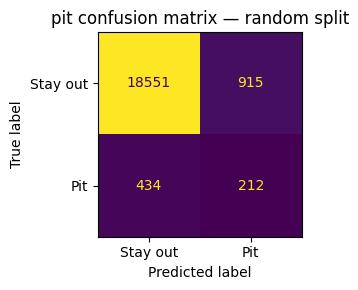


training pit model (temporal split)
best threshold (val set): 0.6667
precision: 0.7778
recall: 0.2500
F1: 0.3784
pit model evaluation (temporal split)
threshold: 0.6667
AUC-PR: 0.0941
F1: 0.1777
              precision    recall  f1-score   support

    stay out       0.98      0.88      0.93     25535
         pit       0.11      0.48      0.18       762

    accuracy                           0.87     26297
   macro avg       0.55      0.68      0.55     26297
weighted avg       0.96      0.87      0.91     26297



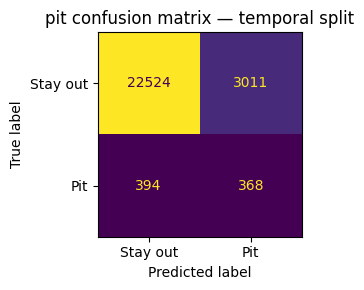


training compound model (random split)
compound model evaluation (random split)
accuracy: 0.6833
              precision    recall  f1-score   support

        HARD       0.67      0.90      0.77       324
INTERMEDIATE       0.00      0.00      0.00         1
      MEDIUM       0.64      0.51      0.56       164
        SOFT       0.84      0.42      0.56       152

    accuracy                           0.68       641
   macro avg       0.54      0.46      0.47       641
weighted avg       0.70      0.68      0.67       641


training compound model (temporal split)
compound model evaluation (temporal split)
accuracy: 0.6342
              precision    recall  f1-score   support

        HARD       0.65      0.75      0.70       318
INTERMEDIATE       0.92      0.89      0.91        27
      MEDIUM       0.64      0.54      0.59       274
        SOFT       0.51      0.48      0.49       130

    accuracy                           0.63       749
   macro avg       0.68      0.67      

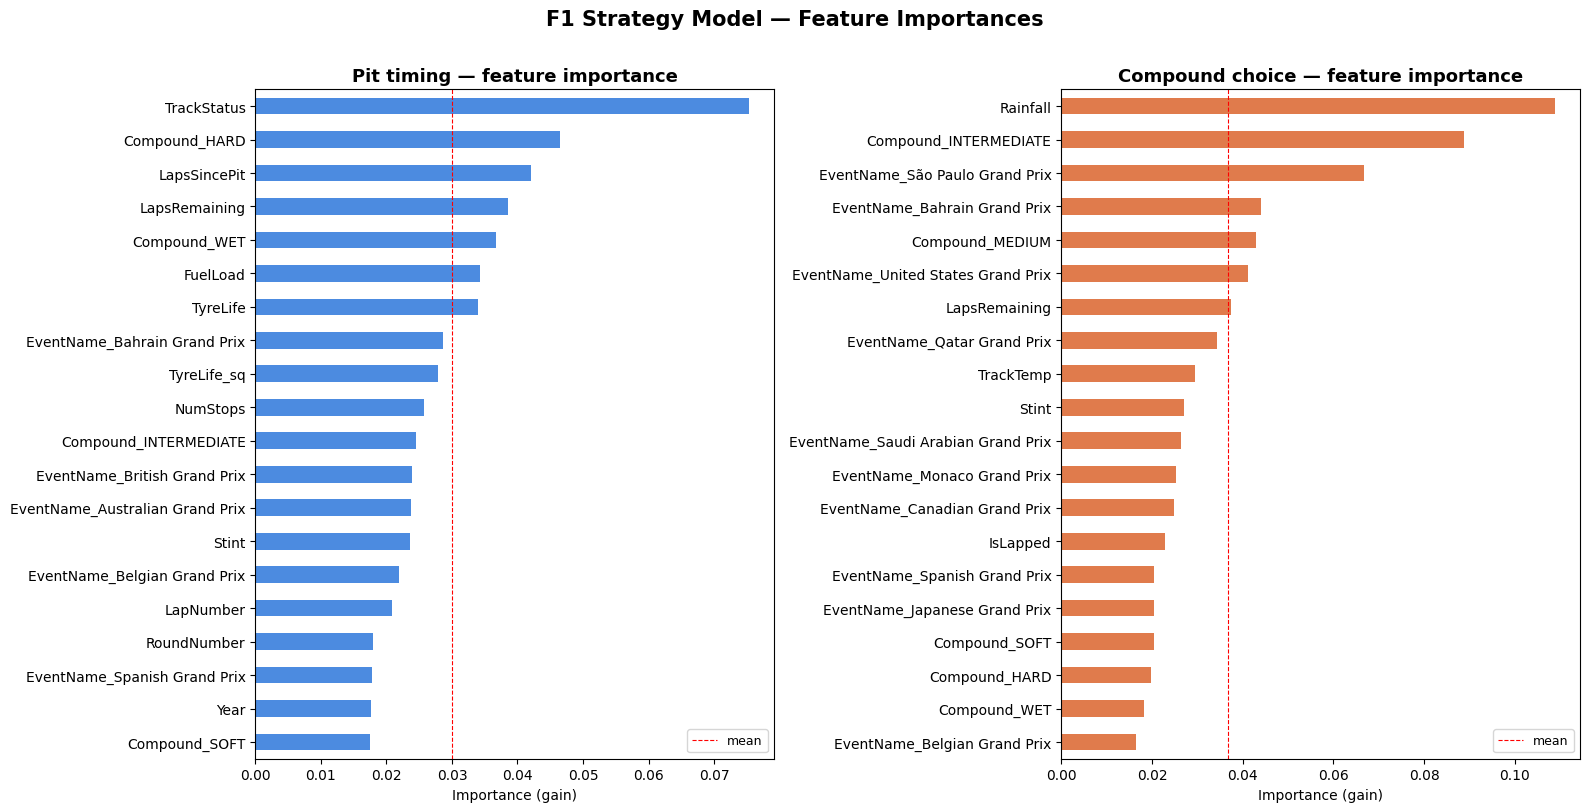

top 10: pit timing
TrackStatus                     0.075382
Compound_HARD                   0.046518
LapsSincePit                    0.042112
LapsRemaining                   0.038589
Compound_WET                    0.036749
FuelLoad                        0.034303
TyreLife                        0.034014
EventName_Bahrain Grand Prix    0.028641
TyreLife_sq                     0.027867
NumStops                        0.025659

top 10: compound choice
Rainfall                              0.108908
Compound_INTERMEDIATE                 0.088810
EventName_São Paulo Grand Prix        0.066688
EventName_Bahrain Grand Prix          0.044082
Compound_MEDIUM                       0.042873
EventName_United States Grand Prix    0.041071
LapsRemaining                         0.037518
EventName_Qatar Grand Prix            0.034361
TrackTemp                             0.029558
Stint                                 0.027042


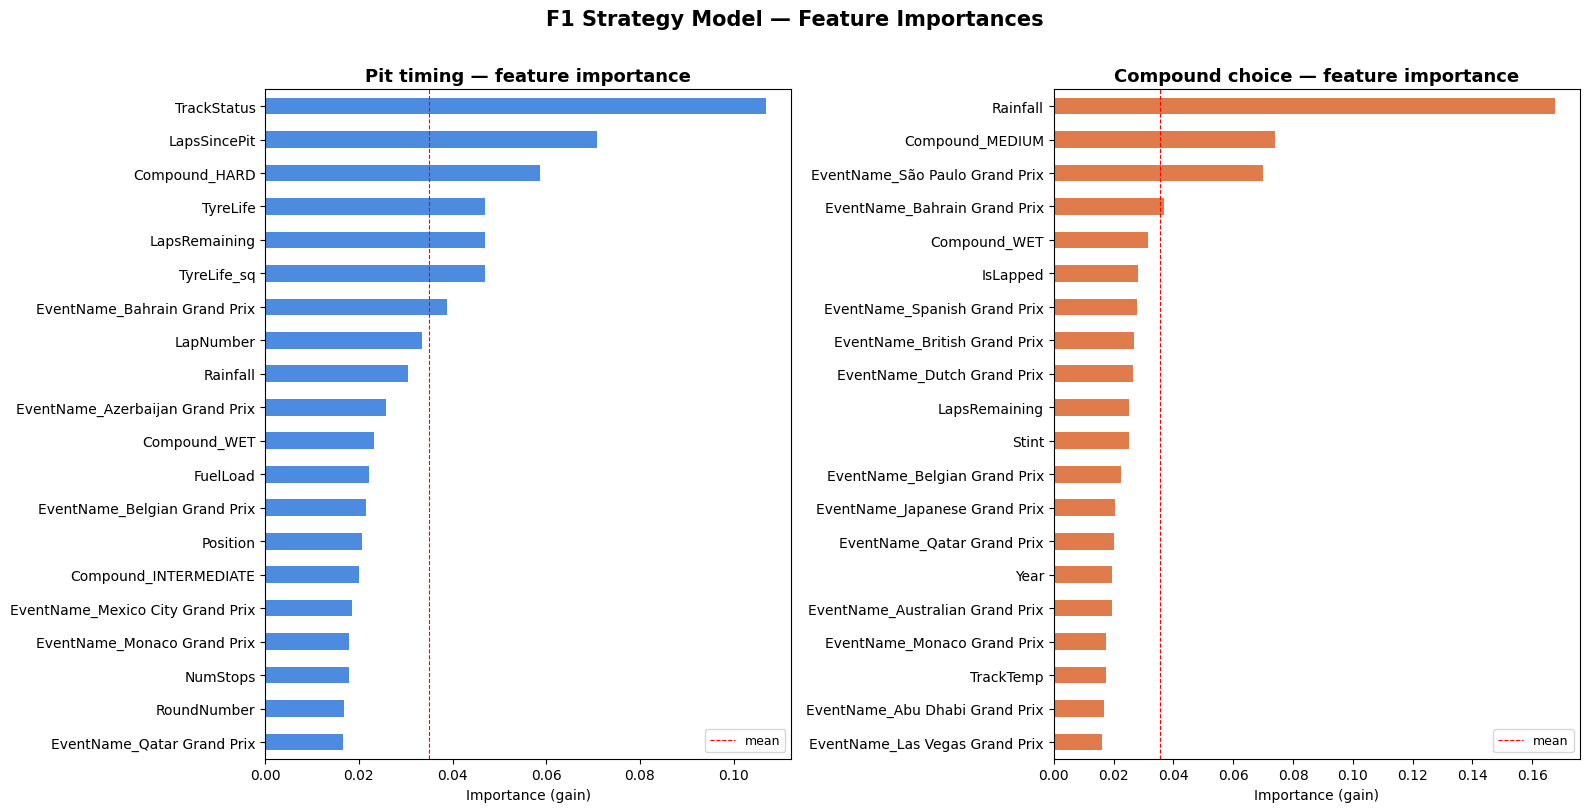

top 10: pit timing
TrackStatus                        0.106999
LapsSincePit                       0.070820
Compound_HARD                      0.058737
TyreLife                           0.046965
LapsRemaining                      0.046916
TyreLife_sq                        0.046907
EventName_Bahrain Grand Prix       0.038740
LapNumber                          0.033448
Rainfall                           0.030496
EventName_Azerbaijan Grand Prix    0.025768

top 10: compound choice
Rainfall                          0.167578
Compound_MEDIUM                   0.074057
EventName_São Paulo Grand Prix    0.069900
EventName_Bahrain Grand Prix      0.036945
Compound_WET                      0.031515
IsLapped                          0.028313
EventName_Spanish Grand Prix      0.027837
EventName_British Grand Prix      0.026749
EventName_Dutch Grand Prix        0.026540
LapsRemaining                     0.025211


In [222]:
if __name__ == "__main__":

    clean = clean_data(lap_data)

    (train_random, val_random, test_random), (train_temporal, val_temporal, test_temporal) = make_splits(clean)

    print(f"random split - train: {len(train_random):,}  val: {len(val_random):,}  test: {len(test_random)}")
    print(f"temporal split - train: {len(train_temporal):,}  val: {len(val_temporal):,}  test: {len(test_temporal)}")

    print("\ntraining pit model (random split)")
    pit_model_random = train_pit_model(train_random, val_random)
    threshold_random = tune_threshold(pit_model_random, val_random)
    evaluate_pit_model(pit_model_random, test_random, threshold=threshold_random, label="random split")

    print("\ntraining pit model (temporal split)")
    pit_model_temporal = train_pit_model(train_temporal, val_temporal)
    threshold_temporal = tune_threshold(pit_model_temporal, val_temporal)
    evaluate_pit_model(pit_model_temporal, test_temporal, threshold=threshold_temporal, label="temporal split")

    print("\ntraining compound model (random split)")
    comp_clf_random, comp_le_random, comp_ct_random = train_compound_model(train_random, val_random)
    evaluate_compound_model(comp_clf_random, comp_le_random, comp_ct_random, test_random, label="random split")

    print("\ntraining compound model (temporal split)")
    comp_clf_temporal, comp_le_temporal, comp_ct_temporal = train_compound_model(train_temporal, val_temporal)
    evaluate_compound_model(comp_clf_temporal, comp_le_temporal, comp_ct_temporal, test_temporal, label="temporal split")

    plot_feature_importance(pit_model_random, comp_clf_random, comp_ct_random)
    plot_feature_importance(pit_model_temporal, comp_clf_temporal, comp_ct_temporal)

### Descriptive Statistics and Exploratory Data Analysis - investigation of features with highest feature importance
##### Pit timing model: "TrackStatus"

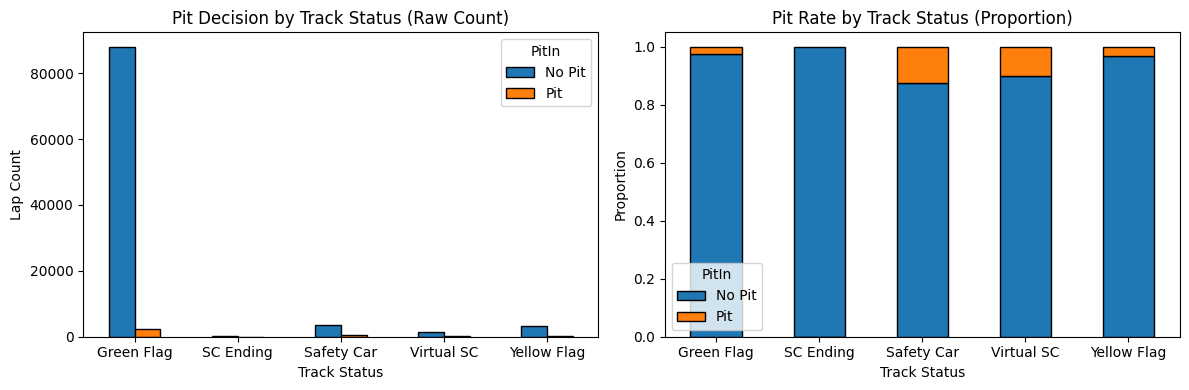

In [396]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df = clean.copy()
plot_df["PitIn"] = plot_df["PitIn"].map({0: "No Pit", 1: "Pit"})
plot_df["TrackStatus"] = plot_df["TrackStatus"].map({"1": "Green Flag", "2": "Yellow Flag", "4": "Safety Car", "6": "Virtual SC", "7": "SC Ending"})

pd.crosstab(plot_df["TrackStatus"], plot_df["PitIn"]).plot(kind="bar", ax=axes[0], edgecolor="black")
axes[0].set_title("Pit Decision by Track Status (Raw Count)")
axes[0].set_xlabel("Track Status")
axes[0].set_ylabel("Lap Count")
axes[0].tick_params(axis="x", rotation=0)

pd.crosstab(plot_df["TrackStatus"], plot_df["PitIn"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1], edgecolor="black")
axes[1].set_title("Pit Rate by Track Status (Proportion)")
axes[1].set_xlabel("Track Status")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

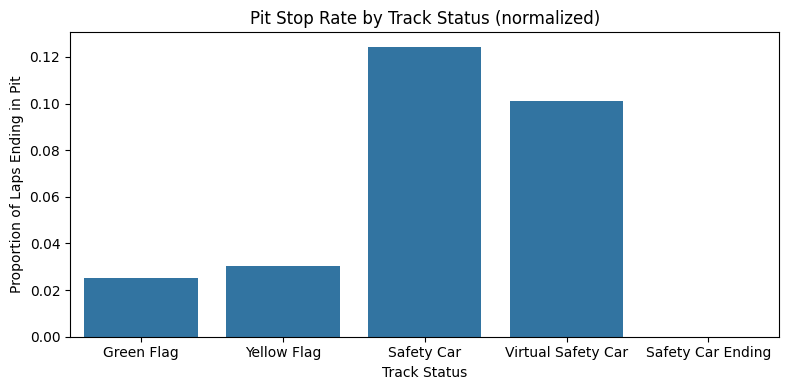

In [274]:
TrackStatusProp = (clean[clean["PitIn"] == 1].groupby("TrackStatus")["PitIn"].count() / clean.groupby("TrackStatus")["PitIn"].count()).reset_index(name="PitProportion")
status_labels = {"1": "Green Flag","2": "Yellow Flag", "4": "Safety Car","6": "Virtual Safety Car","7": "Safety Car Ending"}
TrackStatusProp["TrackStatus"] = TrackStatusProp["TrackStatus"].map(status_labels)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=TrackStatusProp, x="TrackStatus", y="PitProportion", ax=ax)
ax.set_title("Pit Stop Rate by Track Status (normalized)")
ax.set_xlabel("Track Status")
ax.set_ylabel("Proportion of Laps Ending in Pit")
plt.tight_layout()
plt.show()


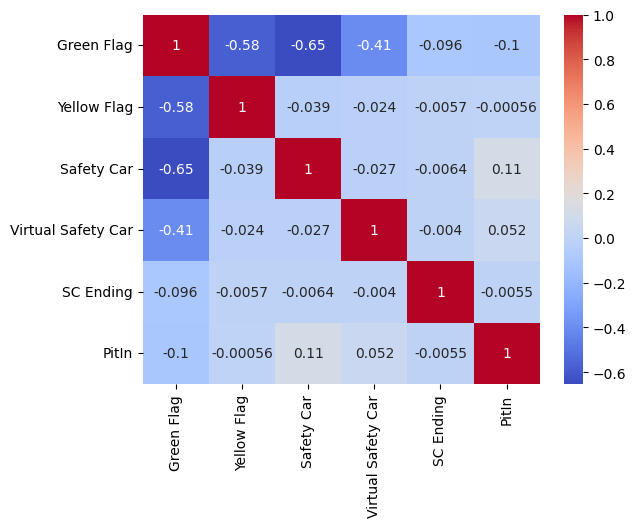

In [260]:
status_dummies = pd.get_dummies(clean["TrackStatus"], prefix="Status")
status_dummies["PitIn"] = clean["PitIn"]
corr_matrix = status_dummies.rename(columns={ "Status_1":"Green Flag", "Status_2":"Yellow Flag", "Status_4":"Safety Car", "Status_6":"Virtual Safety Car", "Status_7":"SC Ending"}).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()


In [269]:
contingency_table = pd.crosstab(clean['TrackStatus'], clean['PitIn'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"p-value: {p}")

n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"cramer's v: {cramers_v:.4f}")

p-value: 0.0
cramer's v: 0.1261


##### Pit timing model: "LapsSincePit" / "TyreLife"

In [ ]:
# central tendency
data = clean["LapsSincePit"].dropna()
mean   = data.mean()
median = data.median()
mode   = data.mode().iloc[0] if not clean["LapsSincePit"].mode().empty else np.nan
    
# variability 
std    = data.std()
var    = data.var()
skew   = data.skew()
kurt   = data.kurtosis()

# 95% margin of error around the mean
n   = len(data)
sem = stats.sem(data)
moe = sem * stats.t.ppf(0.975, df=n - 1)

print(f"n: {n}")
print(f"mean: {mean:.4f} ± {moe:.4f}  (95% MoE)")
print(f"median: {median:.4f}")
print(f"mode: {mode:.4f}")
print(f"std/variance: {std:.4f}/{var:.4f}")
print(f"skewness: {skew:.4f}  ({'right' if skew>0 else 'left'}-skewed)")
print(f"kurtosis: {kurt:.4f}")

n: 99052
mean: 12.8725 ± 0.0636  (95% MoE)
median: 11.0000
mode: 0.0000
std/variance: 10.2192/104.4328
skewness: 1.1749  (right-skewed)
kurtosis: 2.0098


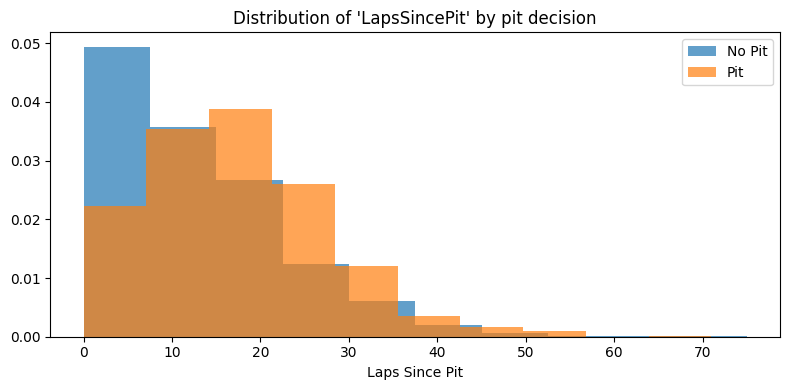

In [312]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.hist(clean[clean["PitIn"] == 0]["LapsSincePit"], label = "No Pit", density=True, alpha=0.7)
plt.hist(clean[clean["PitIn"] == 1]["LapsSincePit"], label = "Pit", density=True, alpha=0.7)
plt.title("Distribution of 'LapsSincePit' by pit decision")
plt.xlabel("Laps Since Pit")
plt.legend()
plt.tight_layout()
plt.show()

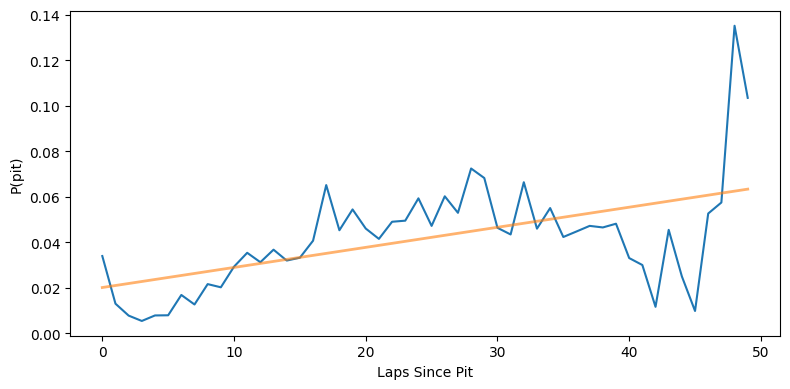

In [332]:
fig, ax = plt.subplots(figsize=(8, 4))
pit_prob = clean.groupby("LapsSincePit")["PitIn"].mean().sort_index()
pit_prob = pit_prob.iloc[:50]

x = pit_prob.index.values
y = pit_prob.values
coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

ax.plot(x, y, label="Observed")
ax.plot(x, trend(x), alpha=0.6, linewidth=2, label="Linear trend")
ax.set_ylabel("P(pit)")
ax.set_xlabel("Laps Since Pit")
plt.tight_layout()
plt.show()

In [335]:
pit = clean[clean["PitIn"] == 1]["LapsSincePit"].dropna()
no_pit = clean[clean["PitIn"] == 0]["LapsSincePit"].dropna()

t_stat, p_ttest = stats.ttest_ind(pit, no_pit, equal_var=False)
print(f"pit mean: {pit.mean():.4f}")
print(f"no-pit mean: {no_pit.mean():.4f}")
print(f"t-test: t = {t_stat:.3f}, p = {p_ttest:.4e} ({'significant' if p_ttest<0.05 else 'not significant'})")

pit mean: 17.3682
no-pit mean: 12.7287
t-test: t = 24.481, p = 1.2083e-121 (significant)


##### Compound model: "Rainfall"

In [362]:
compound_df = clean.copy()
compound_df["NextCompound"] = compound_df.groupby(["Driver", "Year", "EventName"])["Compound"].shift(-1)
compound_df = compound_df[(compound_df["PitIn"] == 1) & (compound_df["NextCompound"].isin(["SOFT","MEDIUM","HARD","INTERMEDIATE"]))]

print(clean["Rainfall"].value_counts())
print(f"\nMean (pit rate proxy): {clean['Rainfall'].mean():.4f}")
print(f"% Wet laps: {clean['Rainfall'].mean()*100:.2f}%")
print(f"mode: {compound_df['NextCompound'].mode()[0]}")

dry = clean[clean["Rainfall"] == 0]["PitIn"]
wet = clean[clean["Rainfall"] == 1]["PitIn"]

# 95% CI on each group's pit rate
for label, group in [("dry", dry), ("wet", wet)]:
    mean = group.mean()
    moe  = stats.t.ppf(0.975, df=len(group)-1) * stats.sem(group)
    print(f"{label} pit rate: {mean:.4f} ± {moe:.4f} (95% MoE)")

Rainfall
False    95702
True      3796
Name: count, dtype: int64

Mean (pit rate proxy): 0.0382
% Wet laps: 3.82%
mode: HARD
dry pit rate: 0.0301 ± 0.0011 (95% MoE)
wet pit rate: 0.0501 ± 0.0069 (95% MoE)


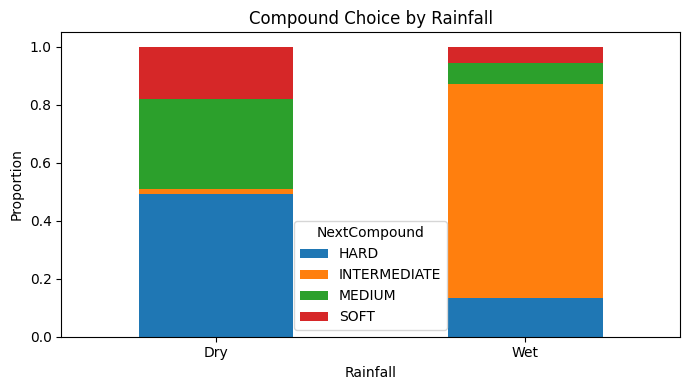

In [ ]:
pd.crosstab(compound_df["Rainfall"], compound_df["NextCompound"], normalize="index").plot(kind="bar", stacked=True, figsize=(7,4))
plt.title("Compound Choice by Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("Proportion")
plt.xticks([0, 1], ["Dry", "Wet"], rotation=0)
plt.tight_layout()
plt.show()

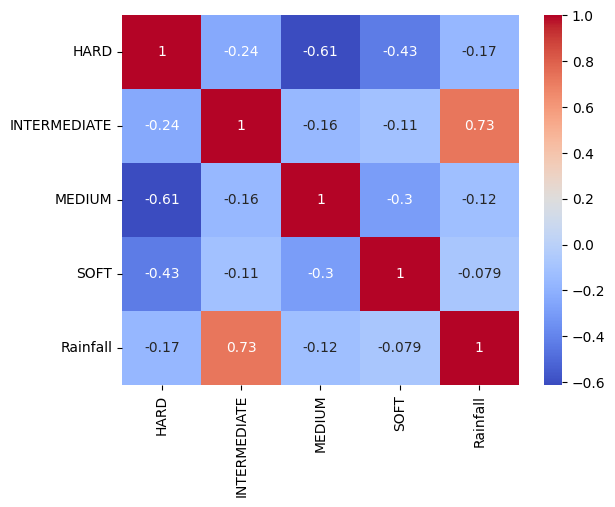

In [350]:
compound_dummies = pd.get_dummies(compound_df["NextCompound"], prefix="Compound")
compound_dummies["Rainfall"] = clean["Rainfall"]
corr_matrix = compound_dummies.rename(columns={ "Compound_HARD":"HARD", "Compound_INTERMEDIATE":"INTERMEDIATE", "Compound_MEDIUM":"MEDIUM", "Compound_SOFT":"SOFT"}).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [346]:
ct2 = pd.crosstab(compound_df["Rainfall"], compound_df["NextCompound"])
chi2, p, dof, _ = chi2_contingency(ct2)
n = ct2.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct2.shape) - 1)))
print(f"compound vs rainfall chi-square: {chi2:.4f}, p: {p:.4e}, cramer's v: {cramers_v:.4f}")

compound vs rainfall chi-square: 1607.3764, p: 0.0000e+00, cramer's v: 0.7283


##### Compound model: "Stint"

In [ ]:
# central tendency
data = clean["Stint"].dropna()
mean   = data.mean()
median = data.median()
mode   = data.mode().iloc[0] if not clean["LapsSincePit"].mode().empty else np.nan
    
# variability 
std    = data.std()
var    = data.var()
skew   = data.skew()
kurt   = data.kurtosis()

# 95% margin of error around the mean
n   = len(data)
sem = stats.sem(data)
moe = sem * stats.t.ppf(0.975, df=n - 1)

print(f"n: {n}")
print(f"mean: {mean:.4f} ± {moe:.4f}  (95% MoE)")
print(f"median: {median:.4f}")
print(f"mode: {mode:.4f}")
print(f"std/variance: {std:.4f}/{var:.4f}")
print(f"skewness: {skew:.4f}  ({'right' if skew>0 else 'left'}-skewed)")
print(f"kurtosis: {kurt:.4f}")

print("\n")
print("mean stint by compound choice:")
print(compound_df.groupby("NextCompound")["Stint"].mean().round(3))

n: 99052
mean: 2.0625 ± 0.0059  (95% MoE)
median: 2.0000
mode: 2.0000
std/variance: 0.9529/0.9079
skewness: 0.8947  (right-skewed)
kurtosis: 1.1426


mean stint by compound choice:
NextCompound
HARD            1.467
INTERMEDIATE    2.151
MEDIUM          1.581
SOFT            2.250
Name: Stint, dtype: float64


       average laps  median laps  std dev  number stints
Stint                                                   
1.0           17.74         16.0    11.09           1729
2.0           23.81         23.0    12.09           1697
3.0           20.50         20.0     9.30           1030
4.0           15.89         15.0     9.56            333
5.0           11.09         11.0     8.26            111
6.0            7.58          7.0     5.10             38
7.0            5.00          7.0     3.07              8
8.0            6.33          7.0     1.15              3


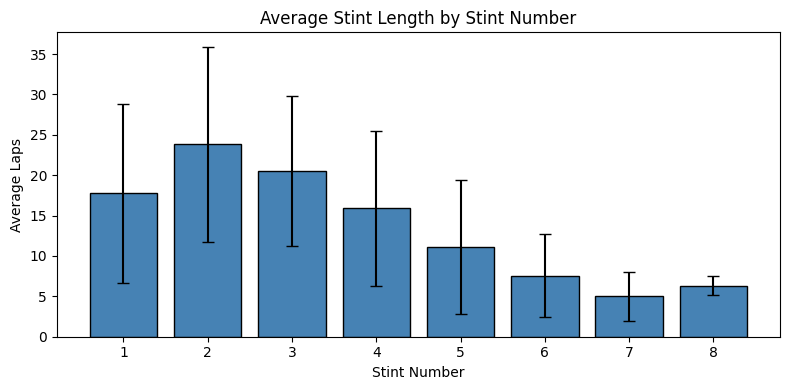

In [389]:
stint_summary = (clean.groupby(["Year", "EventName", "Driver", "Stint"])["LapNumber"].count().reset_index(name="StintLength").groupby("Stint")["StintLength"]
    .agg(["mean", "median", "std", "count"]).round(2).rename(columns={"mean": "average laps", "median": "median laps", "std": "std dev", "count": "number stints"}))
print(stint_summary)

fig, ax = plt.subplots(figsize=(8, 4))

ax.bar(stint_summary.index, stint_summary["average laps"], yerr=stint_summary["std dev"], capsize=4,edgecolor="black", color="steelblue")
ax.set_title("Average Stint Length by Stint Number")
ax.set_xlabel("Stint Number")
ax.set_ylabel("Average Laps")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

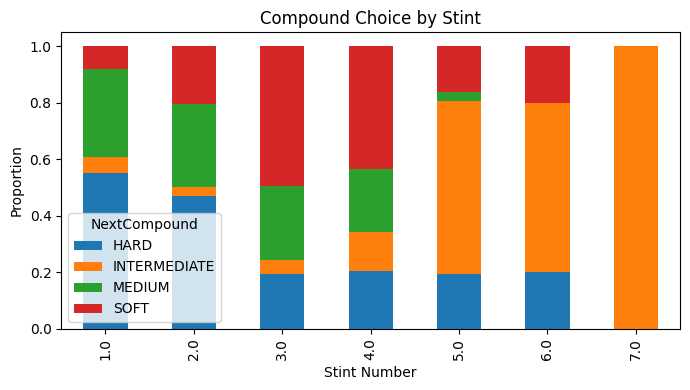

In [398]:
pd.crosstab(compound_df["Stint"], compound_df["NextCompound"], normalize="index").plot(kind="bar", stacked=True, figsize=(7,4))
plt.title("Compound Choice by Stint")
plt.xlabel("Stint Number")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()